# Logistic Regression Baseline Model – Melbourne Water Pipe Failure Prediction
#### Purpose

This notebook builds a **baseline Logistic Regression classification model** using the Melbourne water mains dataset to predict whether a water pipe is at high risk of failure.

A classification model is used to support a **risk identification system**, enabling pipes to be categorised into high-risk and low-risk groups. This approach is more practical for maintenance prioritisation compared to predicting continuous failure values.

#### Expected Outputs

By the end of this notebook, the Logistic Regression workflow should deliver:

- A **baseline pipe failure risk model** for classification
- A **methodologically consistent modelling process** using train, validation, and test sets
- A **final Logistic Regression model** suitable for comparison with other models
- **Final evaluation metrics on the unseen test set**, including:
    - ROC-AUC
    - PR-AUC
    - Precision
    - Recall
    - F1-score
- A **confusion matrix** to assess classification performance
- A **feature importance (coefficient-based) analysis** to interpret model behaviour
- A **probability-based risk output** to support:
    - ranking pipes by failure risk
    - maintenance prioritisation
    - interpretable decision-making

#### Note
- Training set → used to fit the model
- Validation set → used for tuning and comparison
- Test set → used only for final evaluation

This ensures a fair and consistent comparison with other models in the project.

### 1. Dataset Preparation
We'll begin by preparing the dataset for use with our Logistic Regression Model.

In [20]:
import pandas as pd

In [21]:
water = pd.read_csv("../data/processed/cleaned_water_data.csv")

print(water.head())

  ASSET_ID MAIN_LINE_TYPE MAIN_CLASS                       MAIN_NAME MATERIAL  \
0     M474         MAINBG          T  ST GEORGES RD REPLACEMENT MAIN     MSCL   
1     Z060         MAINAG          S       CARDINIA CREEK MINI HYDRO     MSCL   
2     M281         BYPASS          S  CARDINIA-DAND'G-NOTTING HILL M     MSCL   
3     R144         MAINBG          S                 TYABB RESERVOIR       MS   
4     M281         BYPASS          S  CARDINIA-DAND'G-NOTTING HILL M     MSCL   

   PIPE_LENGTH  PIPE_WIDTH SOIL_TYPE DATE_RELINED DATE_OF_CONSTRUCTION  \
0         2.72        1400       NaN          NaN           2017-12-01   
1         1.88         225       NaN          NaN           2017-12-18   
2         1.74         225      SAND          NaN           2011-08-26   
3       131.30         100       NaN          NaN           2017-02-22   
4         5.26         225      SAND          NaN           2011-08-26   

  SERVICE_STATUS  PIPE_AGE  
0             IN       9.0  
1         

In [22]:
# Drop empty columns and define target variable which will be our target column for modelling
water = water.dropna(subset=["PIPE_AGE"])
y = (water["PIPE_AGE"] > 20).astype(int)

#turns PIPE_AGE into binary values for pipes 20 years older/younger

In [23]:
# Drop columns not currently relevant to our model, which have been limited to ASSET_ID, MAIN_NAME, and DATE_OF_CONSTRUCTION, as there
# are not entirely relevant to our intended output of a risk identifier, creating X
X = water.drop(columns=[
    "ASSET_ID",
    "MAIN_NAME",
    "DATE_OF_CONSTRUCTION",
    "DATE_RELINED",
    "PIPE_AGE" # we're removing PIPE_AGE for X as it's already been used to create the target
])

In [24]:
# Handle any remaining missing values for model
# categorical
categorical_cols = X.select_dtypes(include=["object"]).columns
X[categorical_cols] = X[categorical_cols].fillna("UNKNOWN")

# numeric
numeric_cols = X.select_dtypes(include=["number"]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

/tmp/ipykernel_67443/2000110815.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [25]:
# Encoding categorical variable into numeric form for Logistic Regression modelling as it can not use words directly
X = pd.get_dummies(X, drop_first=True)

### 2. Set Split
For consistency amongst our datasets, we're also going to use the sklearn library to split our dataset into train, validation, and test sets.

#### Training Set
Used to fit the model where the model learns patterns from our data

#### Validation set
Used to tune and compare models with potential to
- test different parameters
- compare model versions
- decide whether changes imporve performance

#### Test set
Primary use case of final evaluation

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

#This specifically splits the data into 70% training, 15% validation, and 15% test

In [27]:
# Check before going further to ensure no columns with missing values
print(X.isnull().sum().sort_values(ascending=False))

PIPE_LENGTH              0
PIPE_WIDTH               0
MAIN_LINE_TYPE_BRANCH    0
MAIN_LINE_TYPE_BYPASS    0
MAIN_LINE_TYPE_CONN      0
                        ..
SOIL_TYPE_SS&C           0
SOIL_TYPE_TOPS           0
SOIL_TYPE_UNKN           0
SOIL_TYPE_UNKNOWN        0
SERVICE_STATUS_WIP       0
Length: 71, dtype: int64


### 3. Initial Training

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

# scales the data for better results
X_train = scaler.fit_transform(X_train) #learns the mean and standard deviation of each column and applies scaling
X_val = scaler.transform(X_val) # applies scaling rules from training set 
X_test = scaler.transform(X_test) # ensures only LEARNED scaling is applied

# creates and trains model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 4. Validation Evaluation

In [29]:
from sklearn.metrics import classification_report

y_val_pred = model.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.87      0.42      0.56       293
           1       0.89      0.99      0.94      1474

    accuracy                           0.89      1767
   macro avg       0.88      0.70      0.75      1767
weighted avg       0.89      0.89      0.88      1767



### 5. Final test Evaluation

In [30]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Generates predicted class labels for the test dataset, alongside 
# generating predicted probabilities for each sample
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_test_prob)) # Measures how well the model distinguishes between high and low risk types
print("Precision:", precision_score(y_test, y_test_pred)) # Measures true high-risk predictions
print("Recall:", recall_score(y_test, y_test_pred)) # Checks how many high-risk pipes the model detected
print("F1 Score:", f1_score(y_test, y_test_pred)) # Combines precision and recall into single score for a balanced performance measure

ROC-AUC: 0.8522485742280732
Precision: 0.9108241082410824
Recall: 0.9860186418109188
F1 Score: 0.94693094629156


## Visualisations
This section will focus on presenting visualisations we can use to evaluate the performance of this Logistic Regression model.

### 1. Confusion Matrix
The purpose of this matrix is to compare our datasets actual and predicted values in order to show us:
- True Negatives (top-left)
- False Positive (top-right)
- Fale Negatives (bottom-left)
- True Positives (bottom-right)

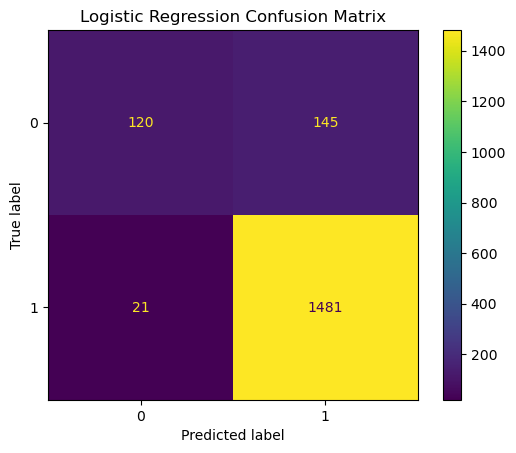

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compare actual and predicted values in order to output them into a 2x2 matrix
cm = confusion_matrix(y_test, y_test_pred)

# Converts matrix into visual plot
ConfusionMatrixDisplay(cm).plot()

# Adds a title and displays plot
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Our matrix shows that us that, out of our results, we were able to identify **1481** high-risk pipes, meaning our Logistic Regression model is good at detecting risk, however, that does not mean it was not void from problems, as there were:

- 145 False positives, meaning safe pipes that were actually high-risk
- 21 False negatives, meaning high risk pipes that were missed
- 120 Genuine low-risk pipes

While there are false positives and negatives identifies, comparatively, it's still a very small margin of error, meaning **The Logistic Regression model is very strong at identifying high-risk pipes**


### 2. Precision-Recall (PR) Curve
This Graph will represent the relationship between Presicion, as a measure of how accurate risk predictions are, and Recall, as a measure of how many at-risk pipes are detected.

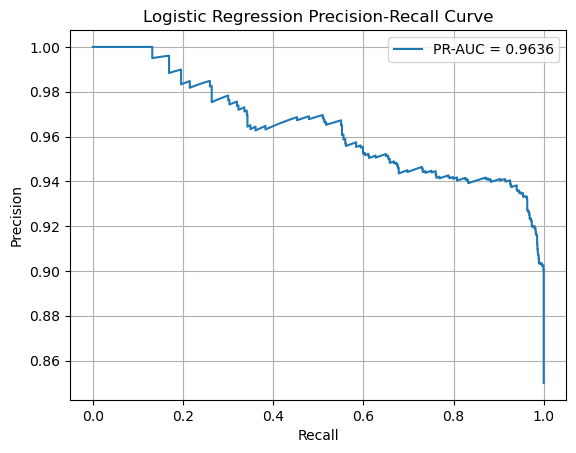

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# uses true labels and predicted probabilities to generate precision values and recall values
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

# Plot the x-axis as recall and y-axis and precision while printing PR_AUC score in legend
plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, y_test_prob):.4f}")

# Title and Axis labels for clarity
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression Precision-Recall Curve")

# Displays plot alongside grid for readability and a legend 
plt.legend()
plt.grid(True)
plt.show()

Our defining factor is our PR-AUC, which stands at **0.9636**, which, is extremely close to 1. This means our model maintained an excellent performance throughout, meaning it has a great balance between detecting risky pipes and avoiding false alarms.

The behaviour of the curve represents a gradual drop as recall gets higher, however, this is an expected tradeoff as the model still manages to maintain relatively high precisison as recall increases.

### 3. Feature Importance
Feature Importance, as opposed to our previous graphs, defines the features which have the most influence on predictions. 

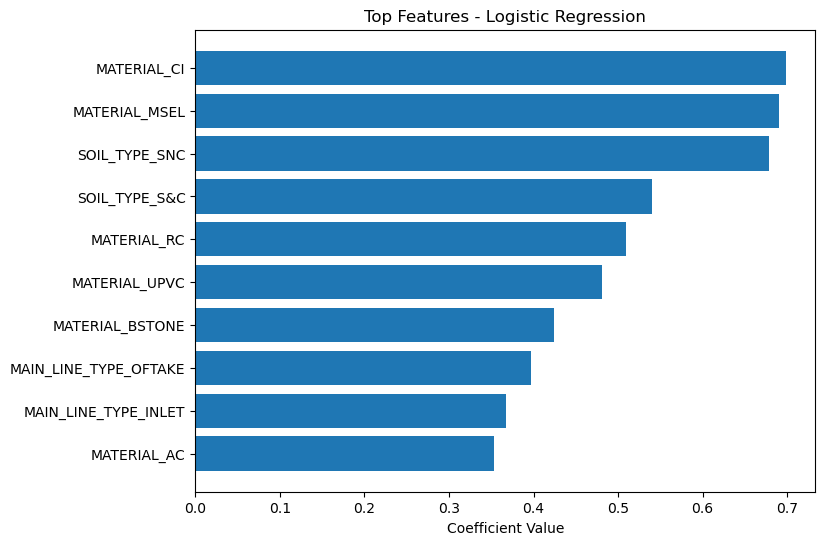

In [33]:
# Creates table with feature names, corresponding coefficiens and learned weights
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

# Sorts features by importance, with highest impact at top
coefficients = coefficients.sort_values(by="Importance", ascending=False)

# set plot size
plt.figure(figsize=(8,6))

# Create horizontal bar chart which shows the top 10 features
plt.barh(coefficients["Feature"][:10], coefficients["Importance"][:10])

# Flips order so the most important is at the top instead of the bottom
plt.gca().invert_yaxis()

# Adds Title and Axis labels, then display plot
plt.title("Top Features - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.show()

From our graph, we can identify that our top features were 

- MATERIAL_CI
- MATERIAL_MSEL
- SOIL_TYPE_SNC
- SOIL_TYPE_S&C
- MATERIAL_SC
- MATERIAL_UPVC

Looking at all of our attained values, Material is the dominant feature set, where multiple material types appear at the top, indicating that pipe material seems to be the dominant risk driver.

However, Soil Type also appears close to the top of the Top Features graph, meaning the soil conditions contribute to failure risk as well, confirming an overall environmental influence to Melbournes Water Pipelines